In [1]:
%pip install kagglehub opencv-python-headless numpy pandas tqdm scikit-learn matplotlib seaborn tensorflow -q


In [2]:
import random
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU disponivel:", tf.config.list_physical_devices("GPU"))


TensorFlow: 2.20.0
GPU disponivel: []


In [3]:
import kagglehub

path = kagglehub.dataset_download("tombackert/brain-tumor-mri-data")
dataset_path = Path(path)

INPUT_BASE = dataset_path / "brain-tumor-mri-dataset"
CLASSES = ["glioma", "meningioma", "notumor", "pituitary"]
TARGET_SIZE = (128, 128)
BASE_DIR = Path.cwd()

100%|██████████| 151M/151M [00:01<00:00, 111MB/s]

Extracting files...


## Fazendo a divisão em train/val/test (estratificado)

In [4]:
def listar_arquivos_por_classe(input_base, classes):
    dados = {}
    for c in classes:
        class_dir = input_base / c
        arquivos = sorted([f for f in class_dir.glob("*") if f.is_file()])
        dados[c] = arquivos
    return dados


def criar_split(input_base, classes, val_size=0.15, test_size=0.15, seed=SEED):
    """Split estratificado train/val/test a partir das pastas de classe originais."""
    dados = listar_arquivos_por_classe(input_base, classes)
    registros = []

    for classe, arquivos in dados.items():
        if len(arquivos) == 0:
            raise ValueError(f"Nenhum arquivo encontrado para a classe '{classe}' em {input_base / classe}")

        train_val, test = train_test_split(
            arquivos, test_size=test_size, random_state=seed, shuffle=True
        )
        val_fraction_of_train_val = val_size / (1 - test_size)
        train, val = train_test_split(
            train_val, test_size=val_fraction_of_train_val, random_state=seed, shuffle=True
        )

        for f in train:
            registros.append({"filepath": str(f), "classe": classe, "split": "train"})
        for f in val:
            registros.append({"filepath": str(f), "classe": classe, "split": "val"})
        for f in test:
            registros.append({"filepath": str(f), "classe": classe, "split": "test"})

    return pd.DataFrame(registros)


df_split = criar_split(INPUT_BASE, CLASSES)
print(df_split.groupby(["split", "classe"]).size().unstack())
print("\nTotal de imagens:", len(df_split))

df_split.to_csv(BASE_DIR / "split_baseline.csv", index=False)


classe  glioma  meningioma  notumor  pituitary
split                                         
test       244         267      300        264
train     1133        1241     1400       1229
val        244         267      300        264

Total de imagens: 7153


In [5]:
def construir_cnn(input_shape=(128, 128, 1), n_classes=4, seed=SEED):
    tf.random.set_seed(seed)

    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.GlobalAveragePooling2D(),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(n_classes, activation="softmax"),
    ])

#     model = models.Sequential([
#     layers.Input(shape=input_shape),

#     layers.Conv2D(64, 3, padding="same", activation="relu"),
#     layers.MaxPooling2D(2),

#     layers.Conv2D(128, 3, padding="same", activation="relu"),
#     layers.MaxPooling2D(2),

#     layers.GlobalAveragePooling2D(),
#     layers.Dense(64, activation="relu"),
#     layers.Dropout(0.5),
#     layers.Dense(n_classes, activation="softmax")
#     ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


construir_cnn().summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 83,012 (324.27 KB)

 Trainable params: 83,012 (324.27 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1,
    horizontal_flip=True,
)
eval_datagen = ImageDataGenerator(rescale=1.0 / 255.0)

def criar_generator(datagen, df, shuffle):
    return datagen.flow_from_dataframe(
        df,
        x_col="filepath",
        y_col="classe",
        target_size=TARGET_SIZE,
        color_mode="grayscale",
        classes=CLASSES,
        class_mode="categorical",
        batch_size=BATCH_SIZE,
        seed=SEED,
        shuffle=shuffle,
    )

train_gen = criar_generator(train_datagen, df_split[df_split["split"] == "train"], shuffle=True)
val_gen = criar_generator(eval_datagen, df_split[df_split["split"] == "val"], shuffle=False)
test_gen = criar_generator(eval_datagen, df_split[df_split["split"] == "test"], shuffle=False)


Found 5003 validated image filenames belonging to 4 classes.
Found 1075 validated image filenames belonging to 4 classes.
Found 1075 validated image filenames belonging to 4 classes.


In [ ]:
EPOCHS = 20
RESULTADOS_DIR = BASE_DIR / "resultados_modelo_base"
RESULTADOS_DIR.mkdir(exist_ok=True)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(len(CLASSES)),
    y=train_gen.classes,
)
class_weights = dict(enumerate(class_weights_array))
print("Class weights:", class_weights)

model = construir_cnn(input_shape=(*TARGET_SIZE, 1), n_classes=len(CLASSES))

checkpoint_path = RESULTADOS_DIR / "melhor_modelo.keras"
cbs = [
    callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
    callbacks.ModelCheckpoint(str(checkpoint_path), monitor="val_loss", save_best_only=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6),
]

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=cbs,
    verbose=1,
)

pd.DataFrame(history.history).to_csv(RESULTADOS_DIR / "history.csv", index=False)


Class weights: {0: np.float64(1.1039276257722859), 1: np.float64(1.007856567284448), 2: np.float64(0.8933928571428571), 3: np.float64(1.0176973148901547)}
Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 29s 182ms/step - accuracy: 0.4086 - loss: 1.2499 - val_accuracy: 0.4958 - val_loss: 1.1455 - learning_rate: 0.0010
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 30s 190ms/step - accuracy: 0.5473 - loss: 1.0975 - val_accuracy: 0.6335 - val_loss: 0.9972 - learning_rate: 0.0010
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 30s 190ms/step - accuracy: 0.5811 - loss: 1.0387 - val_accuracy: 0.5619 - val_loss: 1.0592 - learning_rate: 0.0010
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 30s 191ms/step - accuracy: 0.5962 - loss: 1.0071 - val_accuracy: 0.6447 - val_loss: 0.9564 - learning_rate: 0.0010
Epoch 5/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 30s 191ms/step - accuracy: 0.6042 - loss: 0.9917 - val_accuracy: 0.6465 - val_loss: 0.9245 - learning_rate: 0.0010
Epoch 6/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 30s 191ms/step - accuracy: 0.6

## Avaliação no conjunto de teste

In [ ]:
test_gen.reset()
y_true = test_gen.classes
y_pred_probs = model.predict(test_gen, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

report = classification_report(y_true, y_pred, target_names=CLASSES, output_dict=True)
print(classification_report(y_true, y_pred, target_names=CLASSES))

pd.DataFrame(report).transpose().to_csv(RESULTADOS_DIR / "classification_report.csv")
print(f"\nAcuracia no teste: {report['accuracy']:.4f}")


              precision    recall  f1-score   support

      glioma       0.61      0.52      0.56       244
  meningioma       0.44      0.57      0.50       267
     notumor       0.76      0.76      0.76       300
   pituitary       0.74      0.61      0.67       264

    accuracy                           0.62      1075
   macro avg       0.64      0.62      0.62      1075
weighted avg       0.64      0.62      0.63      1075


Acuracia no teste: 0.6223


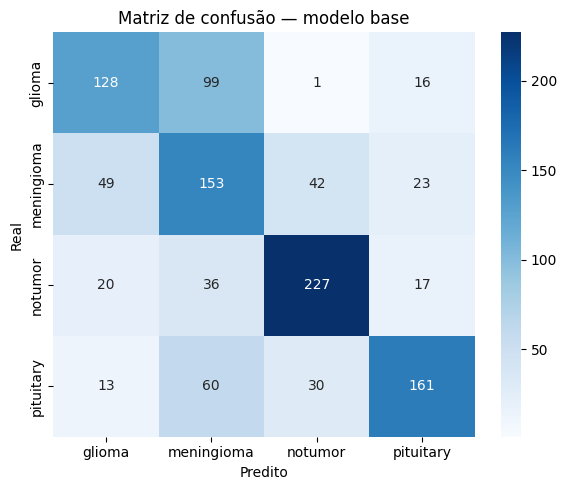

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de confusão — modelo base")
plt.tight_layout()
plt.savefig(RESULTADOS_DIR / "matriz_confusao.png", dpi=150)
plt.show()


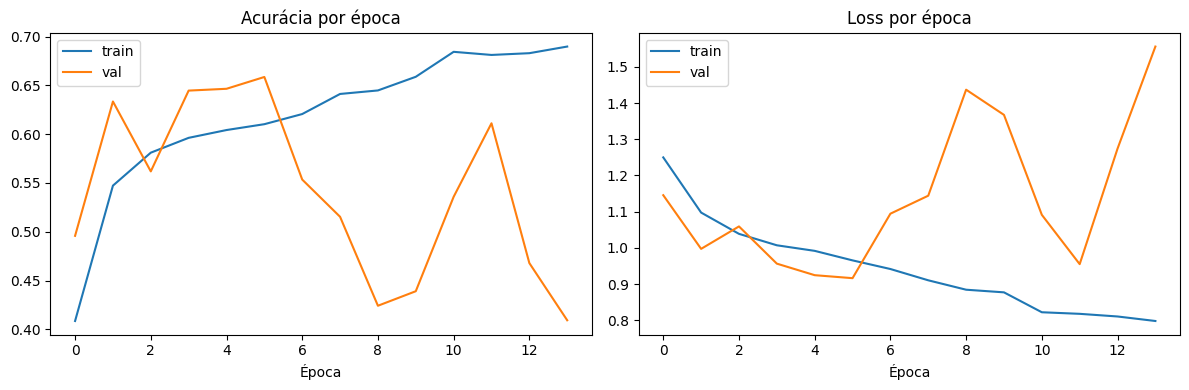

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["accuracy"], label="train")
axes[0].plot(history.history["val_accuracy"], label="val")
axes[0].set_title("Acurácia por época")
axes[0].set_xlabel("Época")
axes[0].legend()

axes[1].plot(history.history["loss"], label="train")
axes[1].plot(history.history["val_loss"], label="val")
axes[1].set_title("Loss por época")
axes[1].set_xlabel("Época")
axes[1].legend()

plt.tight_layout()
plt.savefig(RESULTADOS_DIR / "curvas_treino.png", dpi=150)
plt.show()


In [ ]:
INPUT_BASE_EXP1 = Path("experiment-1") / "dataset_exp1"
TARGET_SIZE_EXP1 = (128, 128)

for c in CLASSES:
    class_dir = INPUT_BASE_EXP1 / c
    n = len(list(class_dir.glob("*"))) if class_dir.exists() else 0
    status = "OK" if class_dir.exists() else "NAO ENCONTRADA -- revise INPUT_BASE_EXP1"
    print(f"{c:12s} -> {class_dir}  [{status}]  ({n} arquivos)")

glioma       -> experiment-1\dataset_exp1\glioma  [OK]  (144 arquivos)
meningioma   -> experiment-1\dataset_exp1\meningioma  [OK]  (1775 arquivos)
notumor      -> experiment-1\dataset_exp1\notumor  [OK]  (2000 arquivos)
pituitary    -> experiment-1\dataset_exp1\pituitary  [OK]  (1757 arquivos)


In [ ]:
df_split_exp1 = criar_split(INPUT_BASE_EXP1, CLASSES)
print(df_split_exp1.groupby(["split", "classe"]).size().unstack())
print("\nTotal de imagens:", len(df_split_exp1))

df_split_exp1.to_csv(BASE_DIR / "split_dataset_exp1.csv", index=False)

classe  glioma  meningioma  notumor  pituitary
split                                         
test        22         267      300        264
train      100        1241     1400       1229
val         22         267      300        264

Total de imagens: 5676


In [ ]:
train_gen_exp1 = criar_generator(train_datagen, df_split_exp1[df_split_exp1["split"] == "train"], shuffle=True)
val_gen_exp1   = criar_generator(eval_datagen, df_split_exp1[df_split_exp1["split"] == "val"], shuffle=False)
test_gen_exp1  = criar_generator(eval_datagen, df_split_exp1[df_split_exp1["split"] == "test"], shuffle=False)

Found 3970 validated image filenames belonging to 4 classes.
Found 853 validated image filenames belonging to 4 classes.
Found 853 validated image filenames belonging to 4 classes.


In [ ]:
EPOCHS_EXP1 = 20
RESULTADOS_DIR_EXP1 = BASE_DIR / "resultados_modelo_exp1"
RESULTADOS_DIR_EXP1.mkdir(exist_ok=True)

class_weights_array_exp1 = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(len(CLASSES)),
    y=train_gen_exp1.classes,
)
class_weights_exp1 = dict(enumerate(class_weights_array_exp1))
print("Class weights:", class_weights_exp1)

model_exp1 = construir_cnn(input_shape=(*TARGET_SIZE_EXP1, 1), n_classes=len(CLASSES))

checkpoint_path_exp1 = RESULTADOS_DIR_EXP1 / "melhor_modelo.keras"
cbs_exp1 = [
    callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
    callbacks.ModelCheckpoint(str(checkpoint_path_exp1), monitor="val_loss", save_best_only=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6),
]

history_exp1 = model_exp1.fit(
    train_gen_exp1,
    validation_data=val_gen_exp1,
    epochs=EPOCHS_EXP1,
    class_weight=class_weights_exp1,
    callbacks=cbs_exp1,
    verbose=1,
)

pd.DataFrame(history_exp1.history).to_csv(RESULTADOS_DIR_EXP1 / "history.csv", index=False)

Class weights: {0: np.float64(9.925), 1: np.float64(0.7997582594681708), 2: np.float64(0.7089285714285715), 3: np.float64(0.807567127746135)}
Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 25s 191ms/step - accuracy: 0.3521 - loss: 1.3749 - val_accuracy: 0.3587 - val_loss: 1.2542 - learning_rate: 0.0010
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 48s 248ms/step - accuracy: 0.4610 - loss: 1.2606 - val_accuracy: 0.5885 - val_loss: 1.1559 - learning_rate: 0.0010
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 31s 249ms/step - accuracy: 0.4783 - loss: 1.2005 - val_accuracy: 0.4889 - val_loss: 1.1108 - learning_rate: 0.0010
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 27s 212ms/step - accuracy: 0.3506 - loss: 1.2832 - val_accuracy: 0.3517 - val_loss: 1.1860 - learning_rate: 0.0010
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 34s 275ms/step - accuracy: 0.4073 - loss: 1.1776 - val_accuracy: 0.3869 - val_loss: 1.2571 - learning_rate: 0.0010
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 34s 273ms/step - accuracy: 0.5020 - loss: 1

In [ ]:
test_gen_exp1.reset()
y_true_exp1 = test_gen_exp1.classes
y_pred_probs_exp1 = model_exp1.predict(test_gen_exp1, verbose=0)
y_pred_exp1 = np.argmax(y_pred_probs_exp1, axis=1)

report_exp1 = classification_report(y_true_exp1, y_pred_exp1, target_names=CLASSES, output_dict=True)
print(classification_report(y_true_exp1, y_pred_exp1, target_names=CLASSES))

pd.DataFrame(report_exp1).transpose().to_csv(RESULTADOS_DIR_EXP1 / "classification_report.csv")
print(f"\nAcuracia no teste: {report_exp1['accuracy']:.4f}")

              precision    recall  f1-score   support

      glioma       0.11      0.41      0.17        22
  meningioma       0.86      0.25      0.38       267
     notumor       0.69      0.83      0.76       300
   pituitary       0.62      0.78      0.69       264

    accuracy                           0.62       853
   macro avg       0.57      0.57      0.50       853
weighted avg       0.71      0.62      0.61       853


Acuracia no teste: 0.6225


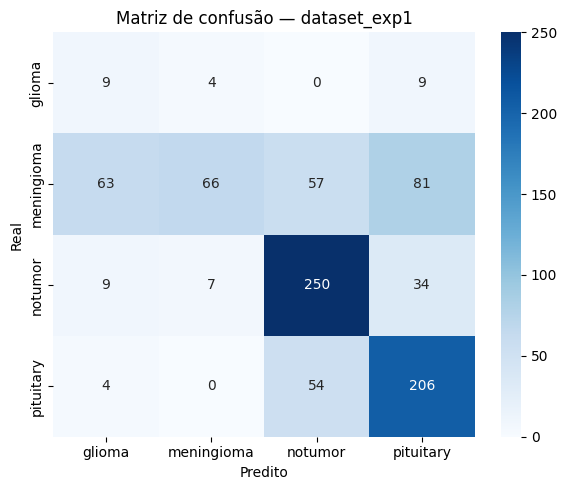

In [ ]:
cm_exp1 = confusion_matrix(y_true_exp1, y_pred_exp1)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_exp1, annot=True, fmt="d", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de confusão — dataset_exp1")
plt.tight_layout()
plt.savefig(RESULTADOS_DIR_EXP1 / "matriz_confusao.png", dpi=150)
plt.show()

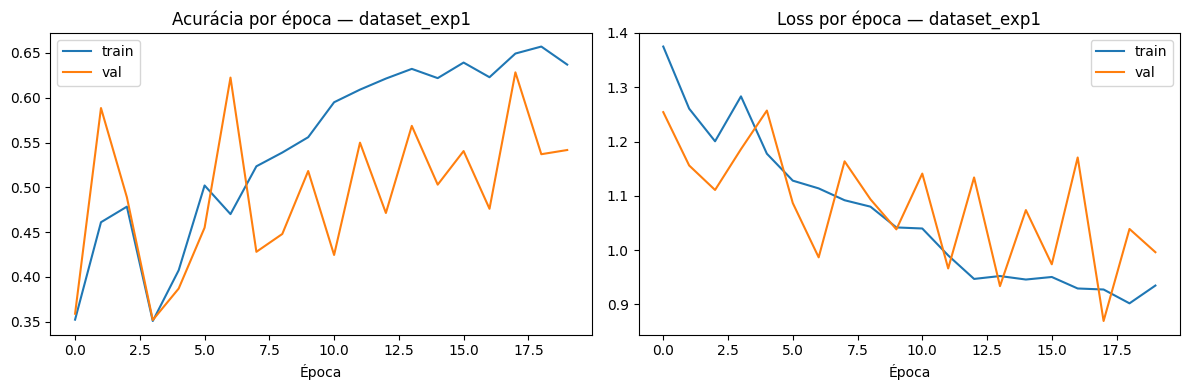

In [ ]:
history_df_exp1 = pd.read_csv(RESULTADOS_DIR_EXP1 / "history.csv")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_df_exp1["accuracy"], label="train")
axes[0].plot(history_df_exp1["val_accuracy"], label="val")
axes[0].set_title("Acurácia por época — dataset_exp1")
axes[0].set_xlabel("Época")
axes[0].legend()

axes[1].plot(history_df_exp1["loss"], label="train")
axes[1].plot(history_df_exp1["val_loss"], label="val")
axes[1].set_title("Loss por época — dataset_exp1")
axes[1].set_xlabel("Época")
axes[1].legend()

plt.tight_layout()
plt.savefig(RESULTADOS_DIR_EXP1 / "curvas_treino.png", dpi=150)
plt.show()

#AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA
#AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA
#AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA